In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score

In [92]:
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [93]:
df.shape

(541909, 8)

In [94]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [96]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Data Preprocessing

In [97]:
df = df.drop('Description', axis=1)

In [98]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df.shape

(530104, 7)

In [99]:
#Since clustering requires the customer id and missing values are not useful for clustering, we will drop them.
df.dropna(subset=['CustomerID'], inplace=True,axis=0)
df.shape

(397884, 7)

In [116]:
print(f'Unique customers: {df["CustomerID"].nunique()}')

Unique customers: 4338


## Feature Engineering

In [100]:
df['Spending'] = df['Quantity'] * df['UnitPrice']

In [101]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [102]:
customer_df = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Spending", "sum")
).reset_index()

In [103]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [104]:
features = customer_df[["Recency", "Frequency", "Monetary"]]

In [105]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Finding the optimal number of clusters (k) using the Elbow method

In [106]:
inertia = []
for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

In [107]:
inertia

[9356.502998161326,
 5498.00625088691,
 4092.1443052542713,
 3141.1018377167875,
 2472.637432047094,
 2022.5081415167947,
 1798.3036040436155,
 1466.1580454703394,
 1305.0204208846585,
 1183.6600667970895]

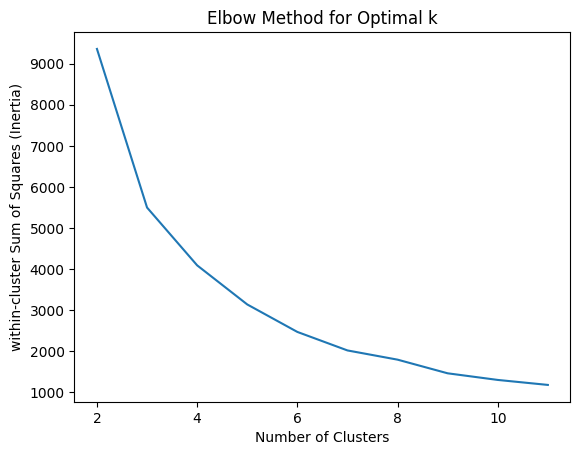

In [108]:
plt.plot(range(2, 12), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("within-cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [109]:
## Verifying the number of clusters using Knee Locator
kneed = KneeLocator(range(2, 12), inertia, curve="convex", direction="decreasing")
print(f"Optimal number of clusters: {kneed.knee}")

Optimal number of clusters: 5


In [110]:
# TSilhouette Score for different k values
silhouette_coefficient = []
for k in range(2,12):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(scaled_features)
  score = silhouette_score(scaled_features, kmeans.labels_)
  silhouette_coefficient.append(score)

In [111]:
silhouette_coefficient

[0.5603671809121974,
 0.5924558738342561,
 0.5910364164299591,
 0.5995115794393039,
 0.5031799633857372,
 0.5200140954768309,
 0.49665992272256326,
 0.4777212820388065,
 0.4778905410158893,
 0.4163752824761605]

## Model Training

In [112]:
kmeans = KMeans(n_clusters=5, random_state=42,init='k-means++')
kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [113]:
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)
print(customer_df["Cluster"].value_counts())

Cluster
0    3060
1    1063
3     203
4       6
2       6
Name: count, dtype: int64


In [114]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


## Model Evaluation using Silhouette Score
### Silhouette Score ranges from -1 to 1, where a higher score indicates better-defined clusters.It measures how similar an object is to its own cluster compared to other clusters.

In [115]:
sil_score = silhouette_score(scaled_features, customer_df["Cluster"])
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.6171


## Cluster Profiling

In [119]:
customer_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,4310.00,0
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,1


In [122]:
cluster_summary = customer_df.groupby("Cluster").agg(
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Customers=("CustomerID", "count")
).reset_index()

In [124]:
cluster_summary = cluster_summary.round({
    "Avg Recency (days)": 2,
    "Avg Purchase Frequency": 2,
    "Avg Total Spending": 2
})

In [125]:
print("\nCUSTOMER SEGMENTATION SUMMARY\n")
print(cluster_summary.to_string(index=False))


CUSTOMER SEGMENTATION SUMMARY

 Cluster  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Customers
       0    43.808170       3.686928   1358.774086             3060
       1   248.469426       1.553151    480.423604             1063
       2     1.500000     135.833333  58381.123333                6
       3    15.724138      22.300493  13533.997044              203
       4     7.666667      42.833333 190863.461667                6


In [128]:
def label_cluster(row):
    if row["Avg_Monetary"] > 50000 and row["Avg_Frequency"] > 100:
        return "Ultra High-Frequency VIPs"
    elif row["Avg_Monetary"] > 100000:
        return "Elite Premium Customers"
    elif row["Avg_Recency"] < 20 and row["Avg_Frequency"] > 15:
        return "Loyal Active Customers"
    elif row["Avg_Recency"] > 150:
        return "Churned Customers"
    else:
        return "Regular Customers"

cluster_summary["Segment"] = cluster_summary.apply(label_cluster, axis=1)

In [129]:
def interpret(row):
    if row["Segment"] == "Elite Premium Customers":
        return "High-value VIP customers."
    elif row["Segment"] == "Ultra High-Frequency VIPs":
        return "Bulk buyers or with extreme purchase frequency."
    elif row["Segment"] == "Loyal Active Customers":
        return "Highly engaged repeat customers."
    elif row["Segment"] == "Churned Customers":
        return "Inactive users"
    else:
        return "Occasional customers"

cluster_summary["Business_Insight"] = cluster_summary.apply(interpret, axis=1)

In [130]:
cluster_summary = cluster_summary.round({
    "Avg_Recency": 2,
    "Avg_Frequency": 2,
    "Avg_Monetary": 2
})

cluster_summary = cluster_summary.sort_values("Avg_Monetary", ascending=False)

In [131]:
from IPython.display import display

display(cluster_summary)

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Customers,Segment,Business_Insight
4,4,7.67,42.83,190863.46,6,Elite Premium Customers,High-value VIP customers.
2,2,1.50,135.83,58381.12,6,Ultra High-Frequency VIPs,Bulk buyers or with extreme purchase frequency.
3,3,15.72,22.30,13534.00,203,Loyal Active Customers,Highly engaged repeat customers.
0,0,43.81,3.69,1358.77,3060,Regular Customers,Occasional customers
1,1,248.47,1.55,480.42,1063,Churned Customers,Inactive users
